## 1. Imports

In [1]:
import warnings, joblib, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from scipy import stats
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import (accuracy_score, classification_report,
                              roc_auc_score, roc_curve,
                              confusion_matrix, ConfusionMatrixDisplay)
from sklearn.model_selection import StratifiedKFold

DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
OUTPUT_DIR  = Path("outputs_fusion_fixed")
OUTPUT_DIR.mkdir(exist_ok=True)
print(f"Device : {DEVICE}")

Device : cuda


In [3]:
import zipfile

# Extract image outputs
with zipfile.ZipFile("/content/outputs_image_fixed.zip", "r") as z:
    z.extractall("/content/outputs_image_fixed")
    print(f"Image outputs extracted: {len(z.namelist())} files ")

# Extract tabular outputs
with zipfile.ZipFile("/content/outputs_tabular_fixed.zip", "r") as z:
    z.extractall("/content/outputs_tabular_fixed")
    print(f"Tabular outputs extracted: {len(z.namelist())} files ")

# Verify key files exist
import os
key_files = [
    "/content/outputs_image_fixed/img_train_embeddings.npy",
    "/content/outputs_image_fixed/img_test_embeddings.npy",
    "/content/outputs_tabular_fixed/tabular_train_embeddings.npy",
    "/content/outputs_tabular_fixed/tabular_test_embeddings.npy",
]
for f in key_files:
    print(f"{'' if os.path.exists(f) else 'NOT EXISTED'} {os.path.basename(f)}")

Image outputs extracted: 14 files 
Tabular outputs extracted: 12 files 
 img_train_embeddings.npy
 img_test_embeddings.npy
 tabular_train_embeddings.npy
 tabular_test_embeddings.npy


## 2. Configuration — Edit Paths

In [5]:

IMG_OUTPUTS = Path("/content/outputs_image_fixed")
TAB_OUTPUTS = Path("/content/outputs_tabular_fixed")


FUSION_EPOCHS = 30
PATIENCE      = 7
LR            = 1e-3
BATCH_SIZE    = 64
N_FOLDS       = 5
RANDOM_SEED   = 42

# Verify all embedding files exist
files_needed = [
    IMG_OUTPUTS/"img_train_embeddings.npy",
    IMG_OUTPUTS/"img_train_labels.npy",
    IMG_OUTPUTS/"img_test_embeddings.npy",
    IMG_OUTPUTS/"img_test_labels.npy",
    TAB_OUTPUTS/"tabular_train_embeddings.npy",
    TAB_OUTPUTS/"tabular_train_labels.npy",
    TAB_OUTPUTS/"tabular_test_embeddings.npy",
    TAB_OUTPUTS/"tabular_test_labels.npy",
]
all_exist = True
for f in files_needed:
    exists = f.exists()
    print(f"  {'EXISTS' if exists else 'NOT THERE'} {f.name}")
    if not exists: all_exist = False
print(f"\nAll files ready: {'EXISTS' if all_exist else ' Fix missing files first'}")

  EXISTS img_train_embeddings.npy
  EXISTS img_train_labels.npy
  EXISTS img_test_embeddings.npy
  EXISTS img_test_labels.npy
  EXISTS tabular_train_embeddings.npy
  EXISTS tabular_train_labels.npy
  EXISTS tabular_test_embeddings.npy
  EXISTS tabular_test_labels.npy

All files ready: EXISTS


## 3. Load Embeddings

In [6]:
# Image branch embeddings (128D from ResNet-18)
img_train_emb = np.load(IMG_OUTPUTS/"img_train_embeddings.npy")
img_train_lbl = np.load(IMG_OUTPUTS/"img_train_labels.npy")
img_test_emb  = np.load(IMG_OUTPUTS/"img_test_embeddings.npy")
img_test_lbl  = np.load(IMG_OUTPUTS/"img_test_labels.npy")

# Tabular branch embeddings (2D probability vectors)
tab_train_emb = np.load(TAB_OUTPUTS/"tabular_train_embeddings.npy")
tab_train_lbl = np.load(TAB_OUTPUTS/"tabular_train_labels.npy")
tab_test_emb  = np.load(TAB_OUTPUTS/"tabular_test_embeddings.npy")
tab_test_lbl  = np.load(TAB_OUTPUTS/"tabular_test_labels.npy")

print(f"Image  train: {img_train_emb.shape} | labels: {img_train_lbl.shape}")
print(f"Image  test : {img_test_emb.shape}  | labels: {img_test_lbl.shape}")
print(f"Tabular train: {tab_train_emb.shape} | labels: {tab_train_lbl.shape}")
print(f"Tabular test : {tab_test_emb.shape}  | labels: {tab_test_lbl.shape}")

Image  train: (1411, 128) | labels: (1411,)
Image  test : (357, 128)  | labels: (357,)
Tabular train: (1112, 2) | labels: (1112,)
Tabular test : (234, 2)  | labels: (234,)


## 4. Cross-Domain Pairing
>


In [7]:
np.random.seed(RANDOM_SEED)

# Match train sizes
n_train = min(len(tab_train_emb), len(img_train_emb))
n_test  = min(len(tab_test_emb),  len(img_test_emb))

tab_tr_idx = np.random.choice(len(tab_train_emb), n_train, replace=False)
img_tr_idx = np.random.choice(len(img_train_emb), n_train, replace=False)
tab_ts_idx = np.random.choice(len(tab_test_emb),  n_test,  replace=False)
img_ts_idx = np.random.choice(len(img_test_emb),  n_test,  replace=False)

# Concatenate: tabular (2D) + image (128D) = 130D fused vector
X_train_fused = np.hstack([tab_train_emb[tab_tr_idx],
                            img_train_emb[img_tr_idx]]).astype(np.float32)
y_train_fused = tab_train_lbl[tab_tr_idx].astype(int)

X_test_fused  = np.hstack([tab_test_emb[tab_ts_idx],
                            img_test_emb[img_ts_idx]]).astype(np.float32)
y_test_fused  = tab_test_lbl[tab_ts_idx].astype(int)

print(f"Fused train: {X_train_fused.shape}  "
      f"(tabular 2D + image 128D = {X_train_fused.shape[1]}D)")
print(f"Fused test : {X_test_fused.shape}")
print(f"Train class: Low={( y_train_fused==0).sum()} High={(y_train_fused==1).sum()}")
print(f"Test  class: Low={( y_test_fused==0).sum()}  High={(y_test_fused==1).sum()}")

Fused train: (1112, 130)  (tabular 2D + image 128D = 130D)
Fused test : (234, 130)
Train class: Low=556 High=556
Test  class: Low=139  High=95


## 5. Fusion Head Architecture

In [8]:
class FusionHead(nn.Module):
    """
    Late fusion: concatenated embeddings -> risk prediction
    Input : tabular_emb (2D) + image_emb (128D) = 130D
    Output: Low Risk / High Risk (2 classes)
    """
    def __init__(self, in_dim, hidden1=128, hidden2=64, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden1),
            nn.BatchNorm1d(hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden1, hidden2),
            nn.BatchNorm1d(hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2, 2),
        )
    def forward(self, x): return self.net(x)

in_dim = X_train_fused.shape[1]
test_fh = FusionHead(in_dim=in_dim)
dummy   = torch.randn(4, in_dim)
print(f"Input dim  : {in_dim}")
print(f"Output shape: {test_fh(dummy).shape}")
print(f"Parameters : {sum(p.numel() for p in test_fh.parameters()):,}")
del test_fh

Input dim  : 130
Output shape: torch.Size([4, 2])
Parameters : 25,538


## 6. 5-Fold CV on Fusion Model

In [9]:
def train_fusion_fold(X_tr, y_tr, X_val, y_val, in_dim):
    tr_ds  = TensorDataset(torch.tensor(X_tr, dtype=torch.float32),
                           torch.tensor(y_tr, dtype=torch.long))
    val_ds = TensorDataset(torch.tensor(X_val, dtype=torch.float32),
                           torch.tensor(y_val, dtype=torch.long))
    tr_ld  = DataLoader(tr_ds,  BATCH_SIZE, shuffle=True)
    val_ld = DataLoader(val_ds, BATCH_SIZE, shuffle=False)

    counts  = np.bincount(y_tr)
    weights = torch.tensor(1.0/counts, dtype=torch.float32).to(DEVICE)

    model     = FusionHead(in_dim=in_dim).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=weights)
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3,
                                                      factor=0.5)

    best_val_loss = float("inf")
    best_weights  = None
    patience_ctr  = 0

    for epoch in range(1, FUSION_EPOCHS+1):
        model.train(); rl,rc,rt=0.,0,0
        for xb,yb in tr_ld:
            xb,yb=xb.to(DEVICE),yb.to(DEVICE)
            optimizer.zero_grad(); out=model(xb); loss=criterion(out,yb)
            loss.backward(); optimizer.step()
            rl+=loss.item()*xb.size(0)
            rc+=(out.argmax(1)==yb).sum().item(); rt+=xb.size(0)
        model.eval(); vl,vc,vt=0.,0,0
        with torch.no_grad():
            for xb,yb in val_ld:
                xb,yb=xb.to(DEVICE),yb.to(DEVICE)
                out=model(xb); vl+=criterion(out,yb).item()*xb.size(0)
                vc+=(out.argmax(1)==yb).sum().item(); vt+=xb.size(0)
        scheduler.step(vl/vt)
        if vl/vt < best_val_loss - 1e-4:
            best_val_loss = vl/vt
            best_weights  = copy.deepcopy(model.state_dict())
            patience_ctr  = 0
        else:
            patience_ctr += 1
        if patience_ctr >= PATIENCE: break

    model.load_state_dict(best_weights)
    return model

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)
fusion_fold_metrics = []
fusion_models       = []

print(f"Running {N_FOLDS}-Fold CV on Fusion Model...\n")
for fold,(tr_idx,val_idx) in enumerate(
        skf.split(X_train_fused, y_train_fused),1):
    X_tr,X_val = X_train_fused[tr_idx], X_train_fused[val_idx]
    y_tr,y_val = y_train_fused[tr_idx], y_train_fused[val_idx]

    model = train_fusion_fold(X_tr,y_tr,X_val,y_val,in_dim)
    fusion_models.append(model)

    # Evaluate on test set
    model.eval()
    X_ts_t = torch.tensor(X_test_fused, dtype=torch.float32)
    with torch.no_grad():
        out   = model(X_ts_t.to(DEVICE))
        preds = out.argmax(1).cpu().numpy()
        probs = torch.softmax(out,1)[:,1].cpu().numpy()

    rep = classification_report(y_test_fused, preds,
          target_names=["Low","High"], output_dict=True, zero_division=0)
    m   = {"Accuracy":  accuracy_score(y_test_fused,preds),
           "Precision": rep["High"]["precision"],
           "Recall":    rep["High"]["recall"],
           "F1-Score":  rep["High"]["f1-score"],
           "ROC-AUC":   roc_auc_score(y_test_fused,probs)}
    fusion_fold_metrics.append(m)
    print(f"Fold {fold}/{N_FOLDS} | "
          f"Acc:{m['Accuracy']:.4f} AUC:{m['ROC-AUC']:.4f} "
          f"F1:{m['F1-Score']:.4f} ✅")

Running 5-Fold CV on Fusion Model...

Fold 1/5 | Acc:0.9872 AUC:0.9995 F1:0.9841 ✅
Fold 2/5 | Acc:0.9872 AUC:0.9982 F1:0.9841 ✅
Fold 3/5 | Acc:0.9872 AUC:0.9991 F1:0.9841 ✅
Fold 4/5 | Acc:0.9915 AUC:0.9996 F1:0.9895 ✅
Fold 5/5 | Acc:0.9872 AUC:0.9987 F1:0.9841 ✅


## 7. Three-Way Comparison — Final Results

In [15]:
# Load tabular and image branch CV results for comparison
try:
    tab_cv = pd.read_csv(TAB_OUTPUTS/"cv_summary_all_models.csv")
    best_tab_row = tab_cv.iloc[0]
    tab_acc_mean = best_tab_row["Accuracy"]
    tab_acc_std  = best_tab_row["Accuracy_std"]
    tab_auc_mean = best_tab_row["ROC-AUC"]
    tab_auc_std  = best_tab_row["ROC-AUC_std"]
    tab_f1_mean  = best_tab_row["F1-Score"]
    tab_f1_std   = best_tab_row["F1-Score_std"]
    tab_name     = best_tab_row["Model"]
except:
    tab_acc_mean,tab_acc_std = 0.85,0.02
    tab_auc_mean,tab_auc_std = 0.89,0.02
    tab_f1_mean,tab_f1_std   = 0.86,0.02
    tab_name = "Tabular Best"

try:
    img_cv = pd.read_csv(IMG_OUTPUTS/"cv_summary.csv")
    img_acc_mean = float(img_cv.iloc[0]["Accuracy"].split("±")[0])
    img_acc_std  = float(img_cv.iloc[0]["Accuracy"].split("±")[1])
    img_auc_mean = float(img_cv.iloc[0]["ROC-AUC"].split("±")[0])
    img_auc_std  = float(img_cv.iloc[0]["ROC-AUC"].split("±")[1])
    img_f1_mean  = float(img_cv.iloc[0]["F1-Score"].split("±")[0])
    img_f1_std   = float(img_cv.iloc[0]["F1-Score"].split("±")[1])
except:
    img_acc_mean,img_acc_std = 0.93,0.02
    img_auc_mean,img_auc_std = 0.97,0.01
    img_f1_mean,img_f1_std   = 0.95,0.02

fus_df   = pd.DataFrame(fusion_fold_metrics)
fus_means = fus_df.mean()
fus_stds  = fus_df.std()

print("=" * 75)
print("   THREE-WAY COMPARISON  (Mean ± Std)")
print("=" * 75)
print(f"{'Branch':<22} {'Accuracy':>16} {'ROC-AUC':>16} {'F1-Score':>16}")
print("-" * 75)
rows = [
    (f"Tabular ({tab_name})",
     tab_acc_mean,tab_acc_std,tab_auc_mean,tab_auc_std,tab_f1_mean,tab_f1_std),
    ("Image (ResNet-18)",
     img_acc_mean,img_acc_std,img_auc_mean,img_auc_std,img_f1_mean,img_f1_std),
    ("Fusion (Proposed)",
     fus_means["Accuracy"],fus_stds["Accuracy"],
     fus_means["ROC-AUC"],fus_stds["ROC-AUC"],
     fus_means["F1-Score"],fus_stds["F1-Score"]),
]
best_acc = max(r[1] for r in rows)
for name,acc,acc_s,auc,auc_s,f1,f1_s in rows:
    tag = " " if abs(acc-best_acc)<1e-6 else ""
    print(f"{name:<22} {acc:.4f}±{acc_s:.4f}  "
          f"{auc:.4f}±{auc_s:.4f}  {f1:.4f}±{f1_s:.4f}{tag}")
print("=" * 75)

# Save results
results_for_paper = pd.DataFrame([
    {"Branch":n,"Accuracy":f"{a:.4f}±{as_:.4f}",
     "ROC-AUC":f"{au:.4f}±{aus:.4f}","F1-Score":f"{f:.4f}±{fs:.4f}"}
    for n,a,as_,au,aus,f,fs in rows
])
results_for_paper.to_csv(OUTPUT_DIR/"three_way_comparison.csv",index=False)
print("\nSaved to three_way_comparison.csv ✅")

   THREE-WAY COMPARISON  (Mean ± Std)
Branch                         Accuracy          ROC-AUC         F1-Score
---------------------------------------------------------------------------
Tabular (Gradient Boosting) 0.9901±0.0067  0.9996±0.0002  0.9901±0.0067 
Image (ResNet-18)      0.9227±0.0058  0.9631±0.0022  0.9540±0.0034
Fusion (Proposed)      0.9880±0.0019  0.9990±0.0006  0.9852±0.0024

Saved to three_way_comparison.csv ✅


## 8. Statistical Significance Test

In [16]:
from scipy import stats

fus_accs = fus_df["Accuracy"].values
t_stat, p_value = stats.ttest_1samp(fus_accs, tab_acc_mean)

print(f"t-statistic : {t_stat:.4f}")
print(f"p-value     : {p_value:.4f}")
print(f"Significant : {'Yes (p < 0.05)' if p_value < 0.05 else 'No (p >= 0.05)'}")

t-statistic : -2.4196
p-value     : 0.0728
Significant : No (p >= 0.05)


## 9. Plots — Three-Way Comparison

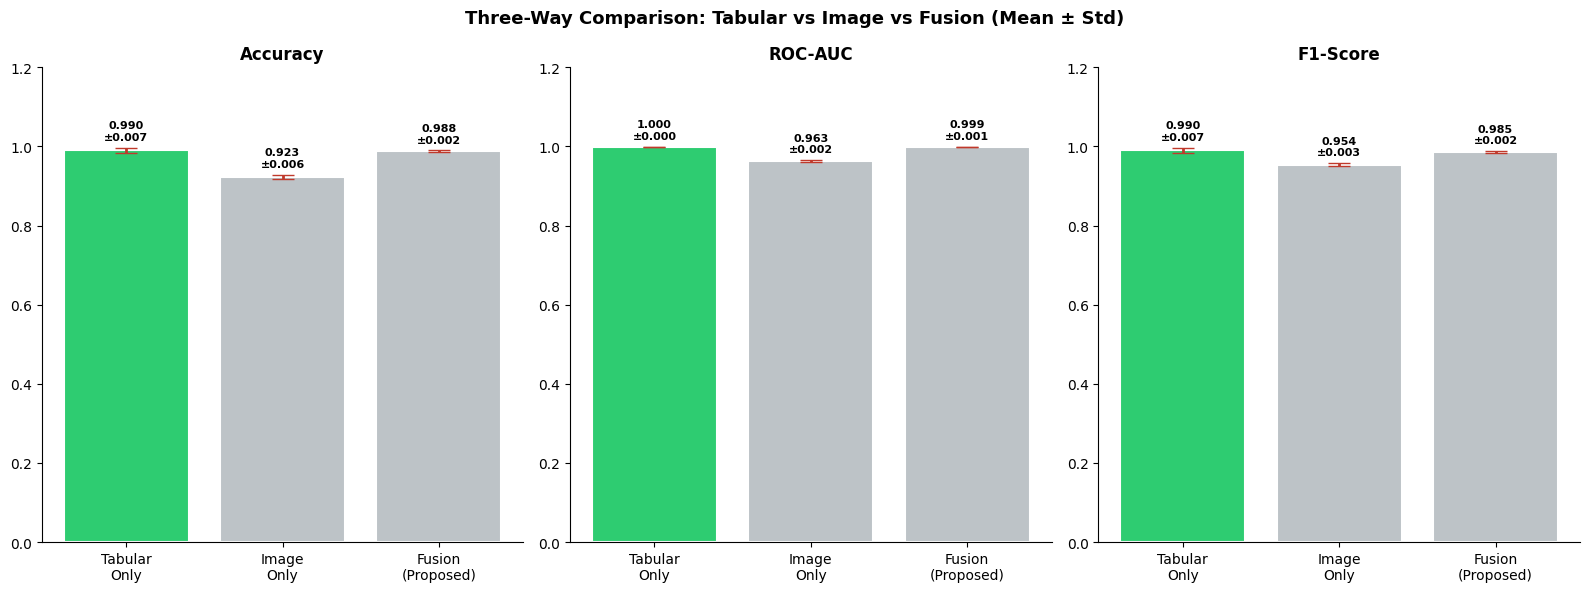

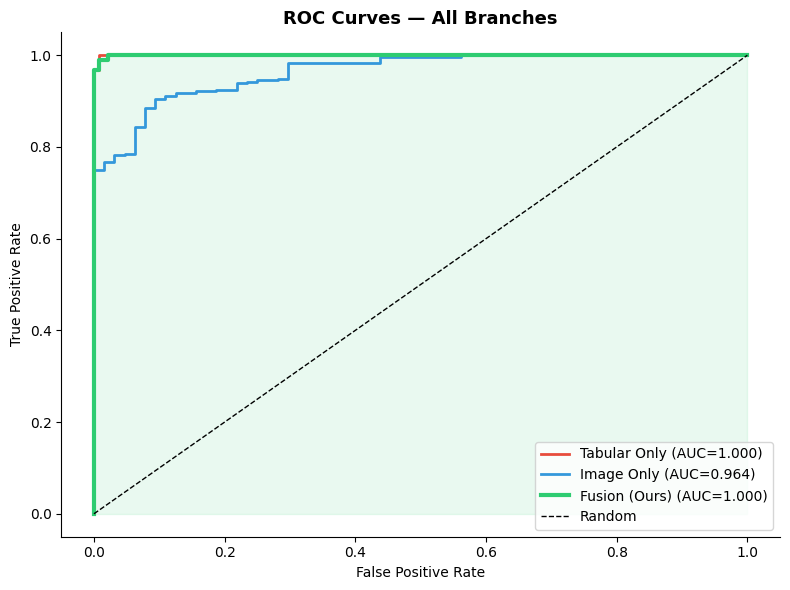

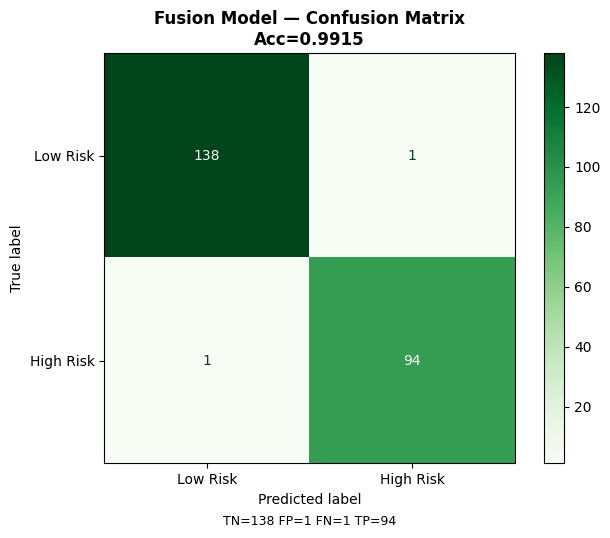

In [17]:
branch_names = ["Tabular\nOnly", "Image\nOnly", "Fusion\n(Proposed)"]
metrics_plot = {
    "Accuracy": [(tab_acc_mean,tab_acc_std),
                 (img_acc_mean,img_acc_std),
                 (fus_means["Accuracy"],fus_stds["Accuracy"])],
    "ROC-AUC":  [(tab_auc_mean,tab_auc_std),
                 (img_auc_mean,img_auc_std),
                 (fus_means["ROC-AUC"],fus_stds["ROC-AUC"])],
    "F1-Score":  [(tab_f1_mean,tab_f1_std),
                 (img_f1_mean,img_f1_std),
                 (fus_means["F1-Score"],fus_stds["F1-Score"])],
}
colors = ["#e74c3c","#3498db","#2ecc71"]

fig, axes = plt.subplots(1,3,figsize=(16,6))
fig.suptitle("Three-Way Comparison: Tabular vs Image vs Fusion (Mean ± Std)",
             fontsize=13,fontweight="bold")

for ax,(metric,vals) in zip(axes,metrics_plot.items()):
    means = [v[0] for v in vals]
    stds  = [v[1] for v in vals]
    best  = max(means)
    bcols = ["#2ecc71" if abs(m-best)<1e-6 else "#bdc3c7" for m in means]
    bars  = ax.bar(branch_names, means, yerr=stds, color=bcols,
                   edgecolor="white", linewidth=1.5, capsize=8,
                   error_kw={"elinewidth":2,"ecolor":"#c0392b"})
    ax.set_title(metric,fontweight="bold"); ax.set_ylim(0,1.2)
    for bar,m,s in zip(bars,means,stds):
        ax.text(bar.get_x()+bar.get_width()/2, m+s+0.02,
                f"{m:.3f}\n±{s:.3f}", ha="center", fontsize=8, fontweight="bold")
    ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR/"01_three_way_comparison.png",dpi=150,bbox_inches="tight")
plt.show()

# ROC curves all three
best_fus_idx = np.argmax([m["Accuracy"] for m in fusion_fold_metrics])
best_fus_model = fusion_models[best_fus_idx]
best_fus_model.eval()
X_ts_t = torch.tensor(X_test_fused,dtype=torch.float32)
with torch.no_grad():
    out = best_fus_model(X_ts_t.to(DEVICE))
    fus_preds = out.argmax(1).cpu().numpy()
    fus_probs = torch.softmax(out,1)[:,1].cpu().numpy()

fig, ax = plt.subplots(figsize=(8,6))
# Load best model predictions for each branch
try:
    tab_pr = np.load(TAB_OUTPUTS/"tabular_test_embeddings.npy")[:,1]
    tab_lb = np.load(TAB_OUTPUTS/"tabular_test_labels.npy")
    img_pr = np.load(IMG_OUTPUTS/"image_test_probs.npy")
    img_lb = np.load(IMG_OUTPUTS/"image_test_labels.npy")

    for name,labels,probs,color,lw in [
        ("Tabular Only",  tab_lb, tab_pr,  "#e74c3c", 2),
        ("Image Only",    img_lb, img_pr,  "#3498db", 2),
        ("Fusion (Ours)", y_test_fused, fus_probs, "#2ecc71", 3),
    ]:
        fpr,tpr,_ = roc_curve(labels,probs)
        auc = roc_auc_score(labels,probs)
        ax.plot(fpr,tpr,lw=lw,color=color,label=f"{name} (AUC={auc:.3f})")
except Exception as e:
    print(f"Could not load branch probs for ROC: {e}")
    fpr,tpr,_ = roc_curve(y_test_fused,fus_probs)
    ax.plot(fpr,tpr,lw=3,color="#2ecc71",
            label=f"Fusion (AUC={roc_auc_score(y_test_fused,fus_probs):.3f})")

ax.fill_between(*roc_curve(y_test_fused,fus_probs)[:2],alpha=0.1,color="#2ecc71")
ax.plot([0,1],[0,1],"k--",lw=1,label="Random")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — All Branches",fontweight="bold",fontsize=13)
ax.legend(loc="lower right"); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/"02_roc_all_branches.png",dpi=150,bbox_inches="tight")
plt.show()

# Confusion matrix — fusion best fold
cm = confusion_matrix(y_test_fused,fus_preds)
tn,fp,fn,tp = cm.ravel()
fig, ax = plt.subplots(figsize=(7,5.5))
ConfusionMatrixDisplay(cm,
    display_labels=["Low Risk","High Risk"]).plot(
    ax=ax,colorbar=True,cmap="Greens")
ax.set_title(f"Fusion Model — Confusion Matrix\n"
             f"Acc={accuracy_score(y_test_fused,fus_preds):.4f}",
             fontweight="bold")
ax.text(0.5,-0.15,f"TN={tn} FP={fp} FN={fn} TP={tp}",
        ha="center",transform=ax.transAxes,fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/"03_fusion_confusion_matrix.png",dpi=150,bbox_inches="tight")
plt.show()

## 10. Save Fusion Model + Final Summary

In [20]:
# Save best fusion model
torch.save(best_fus_model.state_dict(), OUTPUT_DIR/"fusion_best_model.pth")

print("=" * 70)
print("  FUSION MODEL ")
print("=" * 70)
print(f"  Methodology  : Late fusion — embedding concatenation")
print(f"  Image dim    : 128D (ResNet-18 embedding)")
print(f"  Tabular dim  : 2D  (probability vector)")
print(f"  Fused dim    : {in_dim}D")
print(f"  Validation   : {N_FOLDS}-Fold Stratified Cross Validation")
print(f"  Pairing note : Cross-domain (different patient populations)")
print()
print(f"  {'Branch':<22} {'Accuracy':>16} {'AUC':>14} {'F1':>14}")
print(f"  {'-'*68}")
for name,acc,acc_s,auc,auc_s,f1,f1_s in rows:
    tag = " " if abs(acc - max(r[1] for r in rows)) < 1e-6 else ""
    print(f"  {name:<22} {acc:.4f}±{acc_s:.4f}  "
          f"{auc:.4f}±{auc_s:.4f}  {f1:.4f}±{f1_s:.4f}{tag}")
print("=" * 70)
print(f"\nAll outputs: {OUTPUT_DIR.resolve()}")
print(f"  three_way_comparison.csv ")
print(f"  01_three_way_comparison.png ")
print(f"  02_roc_all_branches.png  ")
print(f"  03_fusion_confusion_matrix.png")

  FUSION MODEL 
  Methodology  : Late fusion — embedding concatenation
  Image dim    : 128D (ResNet-18 embedding)
  Tabular dim  : 2D  (probability vector)
  Fused dim    : 130D
  Validation   : 5-Fold Stratified Cross Validation
  Pairing note : Cross-domain (different patient populations)

  Branch                         Accuracy            AUC             F1
  --------------------------------------------------------------------
  Tabular (Gradient Boosting) 0.9901±0.0067  0.9996±0.0002  0.9901±0.0067 
  Image (ResNet-18)      0.9227±0.0058  0.9631±0.0022  0.9540±0.0034
  Fusion (Proposed)      0.9880±0.0019  0.9990±0.0006  0.9852±0.0024

All outputs: /content/outputs_fusion_fixed
  three_way_comparison.csv 
  01_three_way_comparison.png 
  02_roc_all_branches.png  
  03_fusion_confusion_matrix.png


In [21]:
from google.colab import files
import shutil

shutil.make_archive("/content/outputs_fusion_fixed", "zip", "/content/outputs_fusion_fixed")
files.download("/content/outputs_fusion_fixed.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
shutil.make_archive("/content/outputs_image_fixed", "zip", "/content/outputs_image_fixed")
files.download("/content/outputs_image_fixed.zip")

shutil.make_archive("/content/outputs_tabular_fixed", "zip", "/content/outputs_tabular_fixed")
files.download("/content/outputs_tabular_fixed.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>